## **ATS COMPUTER VISION - RE 604**


*Image Classification with Machine Learning Pipeline*


**Nama:** Syerli Khuntum Khaira [ 4222301028]

**Kelas:** RE-6A Pagi



## **1. DATASET PREPARATION**

### a. Import library

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("Import library berhasil.")

Import library berhasil.


### b. Import data

**membaca dataset emnist-letters-train.csv**

In [65]:
df = pd.read_csv("emnist-letters-train.csv", header=None)
print(df.shape)
print(df[0].min() - df[0].max())

(88800, 785)
-25


Separate labels and features

In [66]:
from sklearn.utils import shuffle

In [67]:
df = shuffle(df, random_state=42). reset_index(drop=True)
labels = df.iloc[:,0].values
images = df.iloc[:,1:]. values.reshape(-1, 28, 28)

In [68]:
label_map = {i: chr(64 + i) for i in range(1, 27)}
labels_char = np.array([label_map[lbl] for lbl in labels])


visualisasi satu perkelas

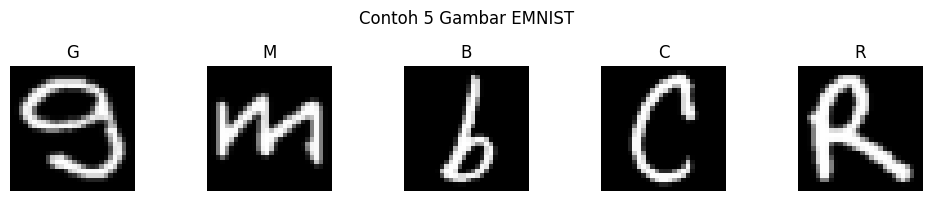

In [69]:
#visualisasi 1 row 7 columns
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i].T, cmap='gray')
    plt.title(labels_char[i])
    plt.axis('off')
plt.suptitle("Contoh 5 Gambar EMNIST")
plt.tight_layout()
plt.show()


In [70]:
df_sorted = df.sort_values(by=0).reset_index(drop=True)


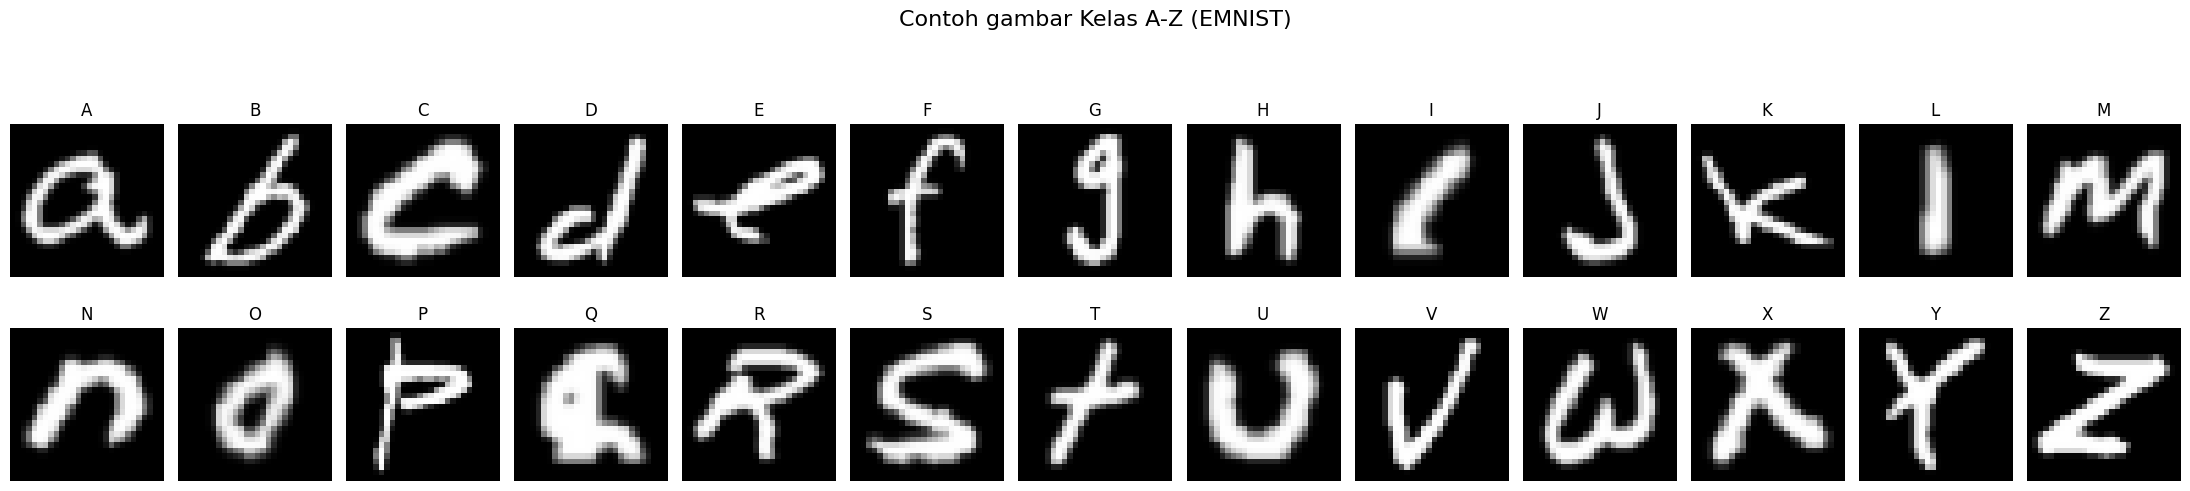

In [88]:
huruf_kapital = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

# Canvas diperbesar menjadi 22x5 agar muat 2 baris x 13 kolom
plt.figure(figsize=(22, 5))

for i in range(26):
    # KUNCI AMAN: Cari nilai target kelas (bisa mulai dari 0 atau 1)
    nilai_min = df_sorted.iloc[:, 0].min()
    target_kelas = i + nilai_min
    
    # Ambil baris pertama yang cocok dari df_sorted (yang sudah pasti berurutan rapi)
    data_baris = df_sorted[df_sorted.iloc[:, 0] == target_kelas].iloc[0, 1:].values
    
    # Reshape ke 28x28 dan Transpose (.T) agar posisi huruf tidak kebalik
    img = data_baris.reshape(28, 28).T
    
    # Menyiapkan posisi grid 2 baris, 13 kolom
    plt.subplot(2, 13, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(huruf_kapital[i], fontsize=12) 
    plt.axis('off')
    
plt.suptitle("Contoh gambar Kelas A-Z (EMNIST)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [72]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    images,
    labels_char,
    test_size=0.20,
    random_state=42,
    stratify=labels_char
)

print(f"\nJumlah Data Training: {len(X_train_raw)} sampel")
print(f"Jumlah Data Testing : {len(X_test_raw)} sampel")


Jumlah Data Training: 71040 sampel
Jumlah Data Testing : 17760 sampel


In [73]:
# Mengacak data agar seimbang 100 sampel per kelas (Total 2600 data)
images_shuffled, labels_shuffled = shuffle(images, labels, random_state=42)

X_selected = []
y_selected = []
counts = {i: 0 for i in range(1, 27)}

for img, lbl in zip(images_shuffled, labels_shuffled):
    if counts[lbl] < 100:
        X_selected.append(img)
        y_selected.append(lbl)
        counts[lbl] += 1
    if sum(counts.values()) == 2600:
        break

X_selected = np.array(X_selected)
y_selected = np.array(y_selected)

print(" X_selected berhasil dibuat")

 X_selected berhasil dibuat


In [74]:
selected_indices = []
for label in range(1, 27):
    idx = np.where(labels == label)[0][:100]
    selected_indices.extend(idx)

selected_images = images[selected_indices]
selected_labels = labels[selected_indices]
selected_labels_char = labels_char[selected_indices]

## **2. FEATURE EXTRACTION MENGGUNAKAN HOG**


In [75]:
#library hog
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler


In [76]:
hog_features = []

for img in X_selected:
    feature = hog(img, orientations=9, pixels_per_cell=(8, 8),
                  cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
    hog_features.append(feature)

hog_features = np.array(hog_features)
print("berhasil")
print(f"Ekstraksi selesai fitur HOG: {hog_features.shape}")

berhasil
Ekstraksi selesai fitur HOG: (2600, 144)


In [77]:
scaler = StandardScaler()
hog_scaled = scaler.fit_transform(hog_features)

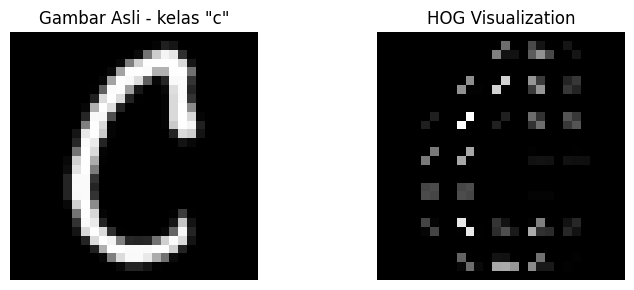

HOG feature vector length : 1296
Parameters -> orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)


In [78]:
# ── Parameter HOG punya kamu ───────────────────────────────────────────────
ORIENTATIONS    = 9      
PIXELS_PER_CELL = (4, 4) 
CELLS_PER_BLOCK = (2, 2) 

# ──>>> [TANDAI - PENYESUAIAN UNTUK HURUF C] <<<──
# Huruf 'c' adalah kelas ke-3 di EMNIST.  cari indeks pertamanya:
idx_target = np.where(labels == 3)[0][0]

sample_img = images[idx_target].reshape(28, 28).T
kelas_angka = labels[idx_target] 

# Memanggil fungsi HOG murni sesuai susunan parameter
feat_sample, hog_img = hog(
    sample_img,
    orientations    = ORIENTATIONS,
    pixels_per_cell = PIXELS_PER_CELL,
    cells_per_block = CELLS_PER_BLOCK,
    visualize       = True,
    block_norm      = 'L2-Hys' 
)

# Menampilkan murni 2 gambar mendatar sesuai variabel fig, (ax1, ax2) 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

ax1.imshow(sample_img, cmap='gray')
ax1.set_title(f'Gambar Asli - kelas "{chr(kelas_angka + 96)}"')
ax1.axis('off')

ax2.imshow(hog_img, cmap='gray') 
ax2.set_title('HOG Visualization')
ax2.axis('off')

plt.tight_layout()
plt.show()

print(f"HOG feature vector length : {feat_sample.shape[0]}")
print(f"Parameters -> orientations={ORIENTATIONS}, "
      f"pixels_per_cell={PIXELS_PER_CELL}, cells_per_block={CELLS_PER_BLOCK}")

## **3. SVM + Grid Search**

In [79]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [80]:
sample_indices = []
for label in range(1, 27):
    idx = np.where(y_selected == label)[0][:15]
    sample_indices.extend(idx)

X_loo = hog_features[sample_indices]
y_loo = y_selected[sample_indices]

In [81]:
param_grid = {
    'C': [1, 10],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf']
}

# Di sini variabel 'clf' resmi dibuat
clf = GridSearchCV(SVC(), param_grid, scoring='accuracy', cv=3)

# KUNCI UTAMA: Gunakan variabel hog_features (hasil array HOG) dan y_selected
clf.fit(X_loo, y_loo)

print("Best Parameters:", clf.best_params_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


## **4. Evaluasi LOOCV**

In [82]:
from sklearn.model_selection import LeaveOneOut

In [83]:
from sklearn import svm
import seaborn as sns
import time

# Pengecekan apakah GridSearch (clf) sudah sukses di-run di atas
if not hasattr(clf, "best_params_"):
    raise ValueError("GridSearchCV (clf) belum di-fit. Jalankan clf.fit(hog_features, y_selected)")

# 100% gaya kodemu, sekarang aman karena 'svm' sudah di-import dan tanda kurung sudah ditutup
best_svm = svm.SVC(
    C=clf.best_params_['C'],
    gamma=clf.best_params_['gamma'],
    kernel=clf.best_params_['kernel']
)


In [84]:
loo = LeaveOneOut()
y_true = []
y_pred = []

start_time = time.time()
for train_idx, test_idx in loo.split(X_loo):
    X_tr, X_te = X_loo[train_idx], X_loo[test_idx]
    y_tr, y_te = y_loo[train_idx], y_loo[test_idx]

    best_svm.fit(X_tr, y_tr)
    pred = best_svm.predict(X_te)

    y_true.append(y_te[0])
    y_pred.append(pred[0])

end_time = time.time()

# Mengubah hasil ke array numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print("Proses LOOCV sukses!")

Proses LOOCV sukses!


5. Matrik evaluasi akhir

In [85]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

In [86]:
# Evaluasi akhir
print("LOOCV Evaluation (520 samples):")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"Execution Time: {end_time - start_time:.2f} seconds\n")


LOOCV Evaluation (520 samples):
Accuracy : 0.6436
Precision: 0.6441
Recall   : 0.6436
F1 Score : 0.6395
Execution Time: 12.88 seconds



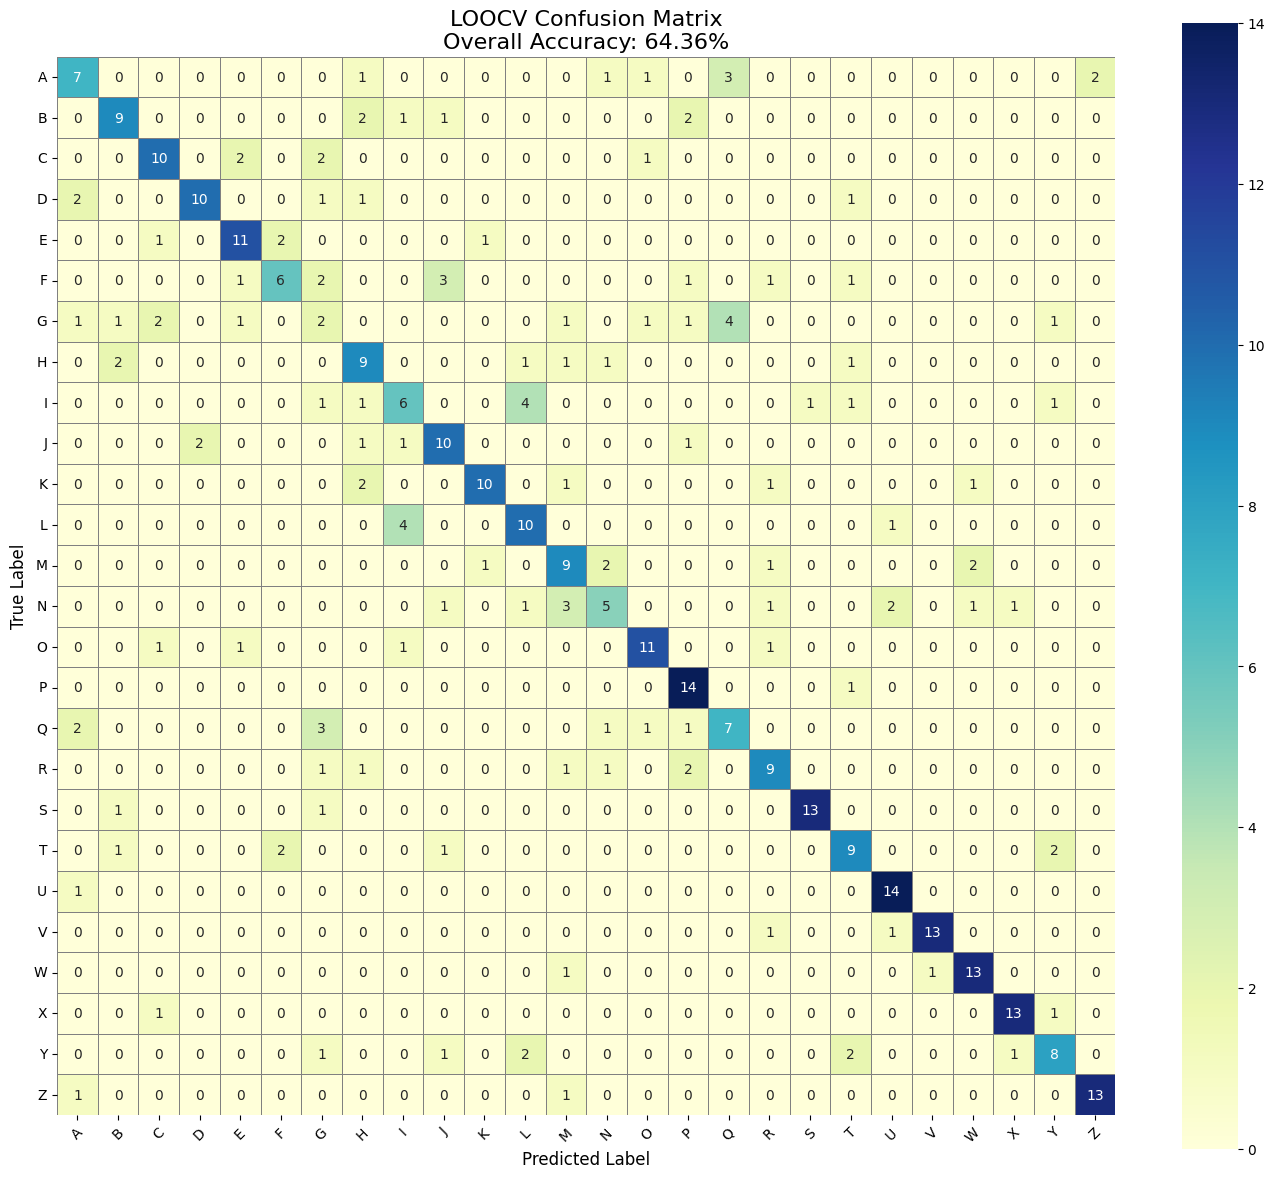

In [87]:
cm = confusion_matrix(y_true, y_pred)

# 2. Menggunakan cara instan kamu untuk list huruf kapital A-Z
labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

# 3. Mengatur ukuran kanvas besar agar pas 26 kelas
plt.figure(figsize=(14, 12))

# 4. Murni gaya visualisasi kode pertama kamu yang sangat detail
sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu",
            xticklabels=labels, yticklabels=labels, cbar=True,
            linewidths=0.5, linecolor='gray', square=True)

# 5. Menghitung akurasi otomatis untuk ditampilkan di judul seperti kodemu
acc = accuracy_score(y_true, y_pred)
plt.title(f"LOOCV Confusion Matrix\nOverall Accuracy: {acc:.2%}", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

# ──>>> TAMBAHAN BIAR GAMBAR MUNCUL SEMPURNA DI VS CODE <<<──
plt.xticks(rotation=45) # Membuat huruf A-Z di bawah agak miring biar gak tabrakan
plt.yticks(rotation=0)  # Membuat huruf A-Z di samping tetap mendatar rapi
plt.tight_layout()      # Memastikan tidak ada teks judul atau label yang terpotong
plt.show()